Shor's Algorithm 2

I removed the operations that made the notebook extremely slow:
❌ DensityMatrix(qc)
❌ partial_trace()
❌ plot_bloch_multivector()
❌ plot_state_qsphere()

Calculating Statevector...
Statevector computed successfully.
Running Aer Simulator...
Simulation Complete.


/var/folders/bx/skxt34z93js03bl2brq7gw8m0000gn/T/ipykernel_16449/3941126773.py:71: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(n_count, inverse=True, do_swaps=True).to_gate()


# Shor's Algorithm (N=15, a=7)

1. Circuit

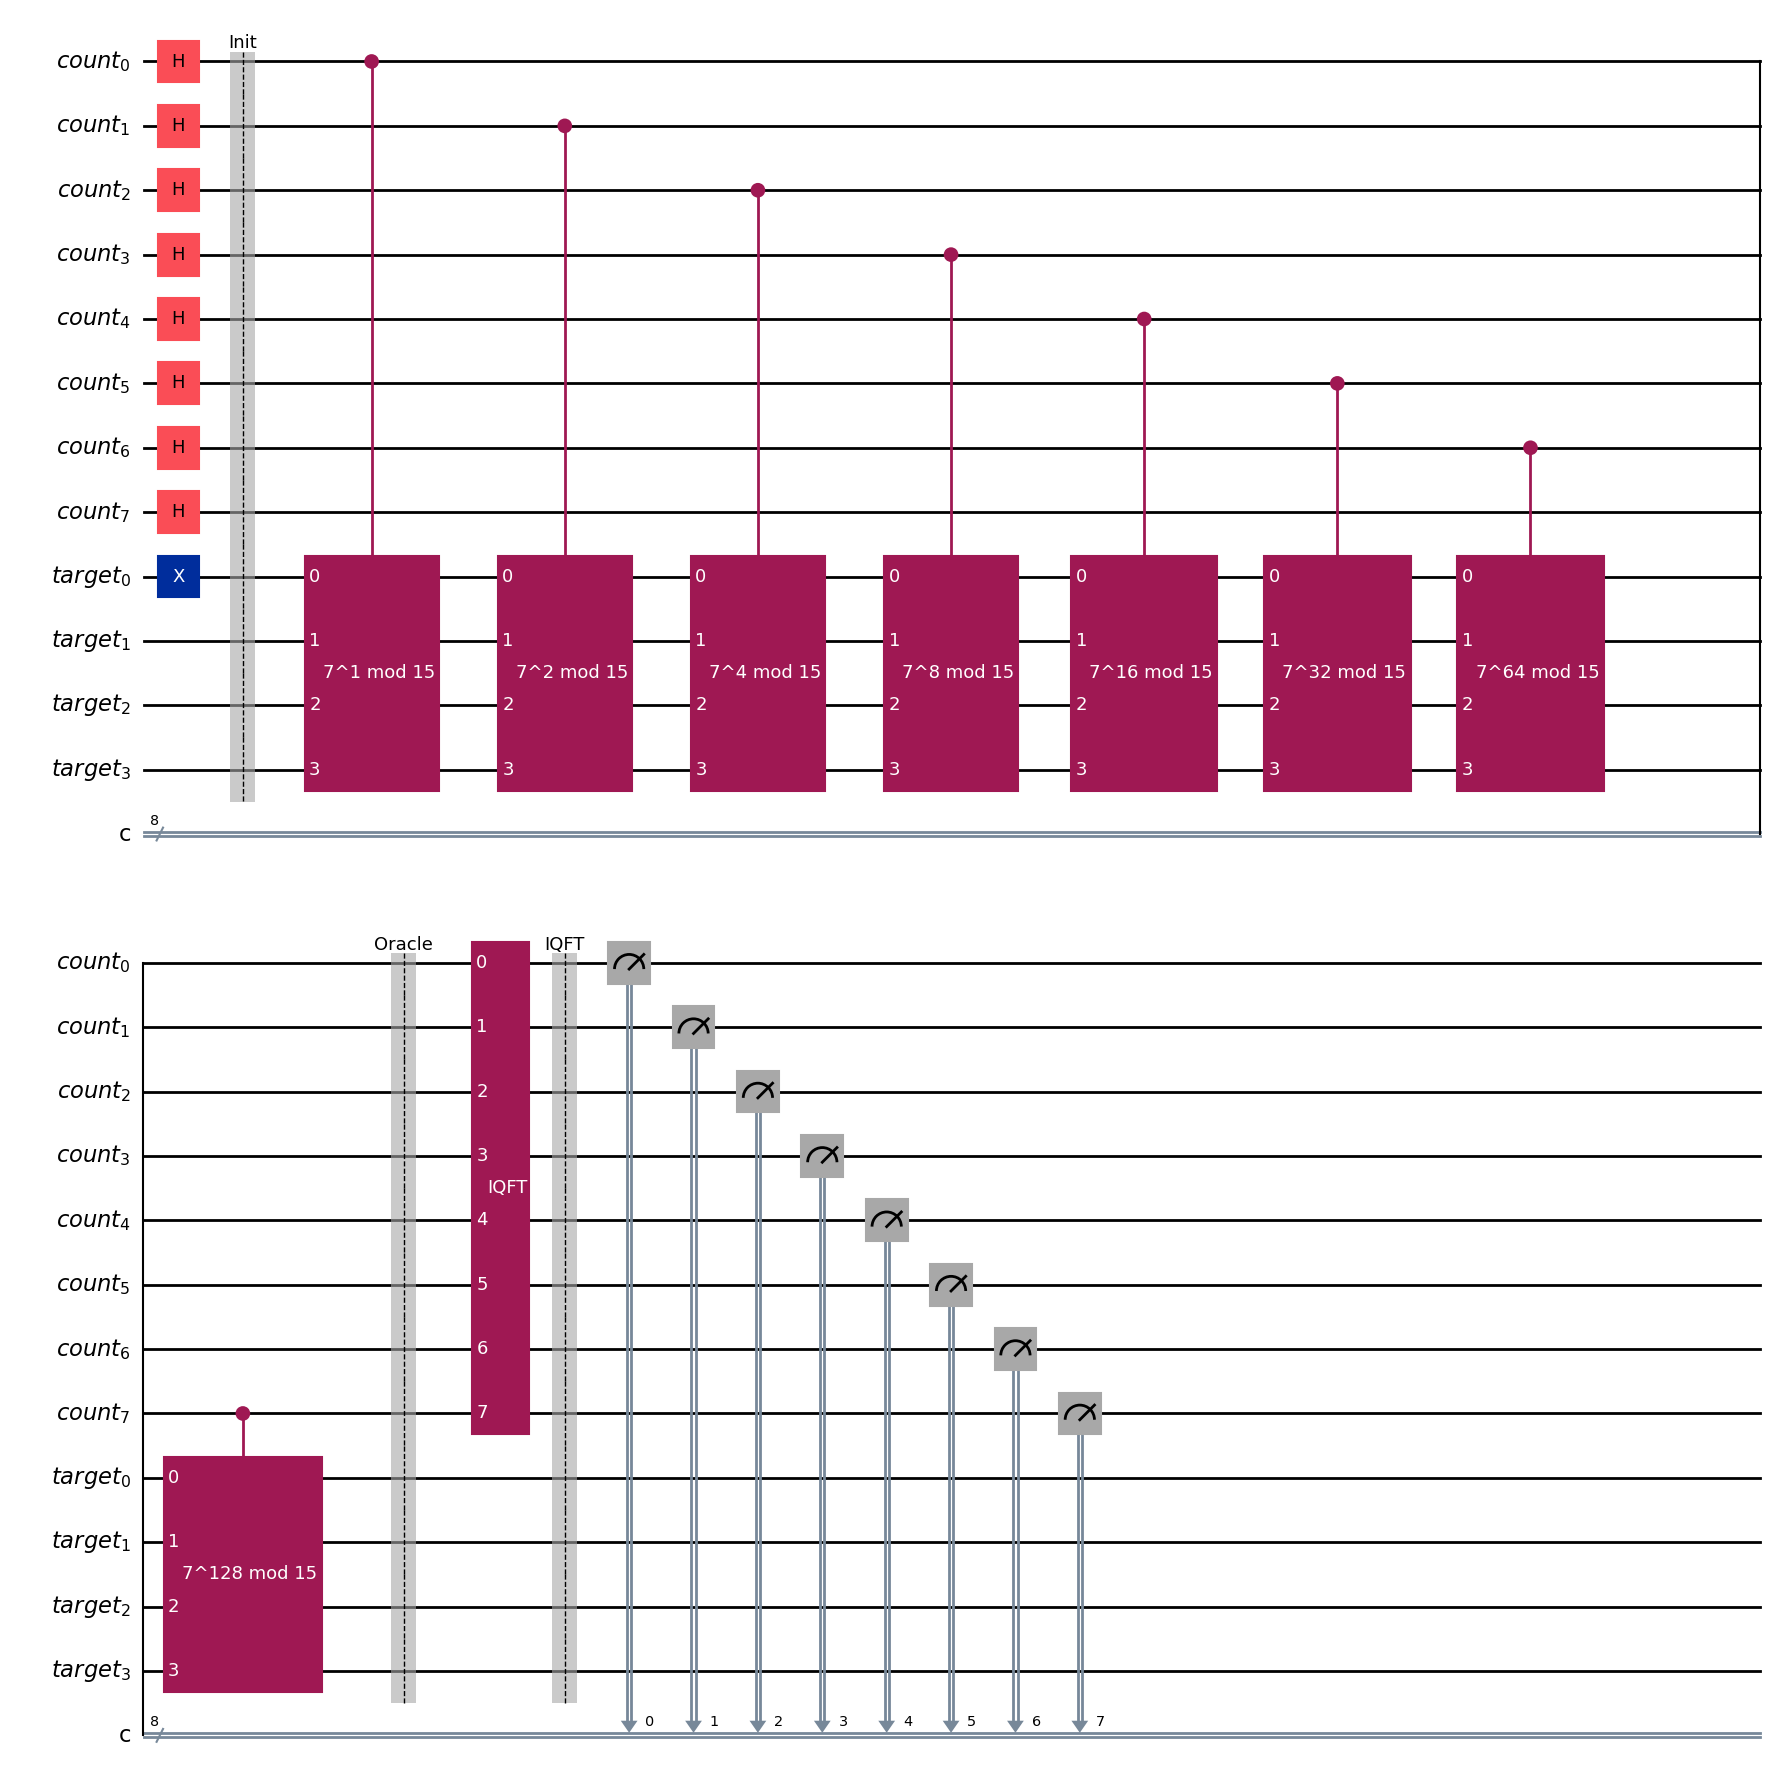

2. Quantum State

Statevector successfully calculated.

Total amplitudes: 4096

First 16 amplitudes:

|000000000000> : 0j
|000000000001> : 0j
|000000000010> : 0j
|000000000011> : 0j
|000000000100> : 0j
|000000000101> : 0j
|000000000110> : 0j
|000000000111> : 0j
|000000001000> : 0j
|000000001001> : 0j
|000000001010> : 0j
|000000001011> : 0j
|000000001100> : 0j
|000000001101> : 0j
|000000001110> : 0j
|000000001111> : 0j


3. Measurement Histogram

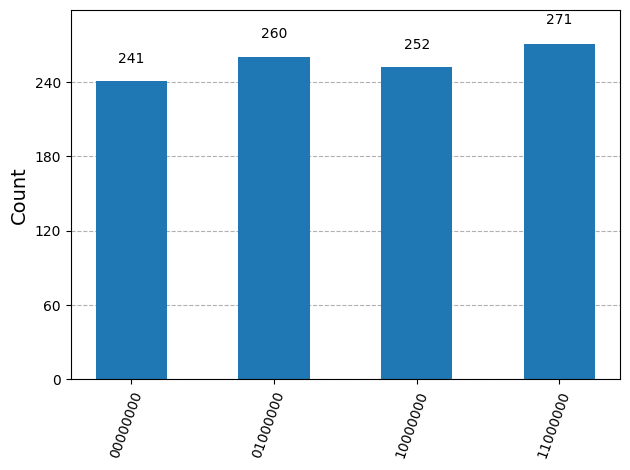

4. Raw Counts

{'00000000': 241, '01000000': 260, '10000000': 252, '11000000': 271}


5. Classical Post-Processing

------------------------------------------------------------
Measured Binary : 11000000
Decimal         : 192
Estimated Phase : 0.750000
Fraction        : 3/4
Estimated Order : 4
gcd(a^(r/2)-1,N) = 3
gcd(a^(r/2)+1,N) = 5

SUCCESS!
Factors of 15 are 3 and 5


In [83]:
import math
from fractions import Fraction

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
from IPython.display import display, Markdown

# ==========================================================
# CONFIGURATION
# ==========================================================

a = 7
N = 15
n_count = 8

# ==========================================================
# Controlled Modular Multiplication
# ==========================================================

def c_amod15(a, power):
    """Controlled multiplication by 7 mod 15."""

    U = QuantumCircuit(4)

    for _ in range(power):
        U.swap(2, 3)
        U.swap(1, 2)
        U.swap(0, 1)

        for q in range(4):
            U.x(q)

    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    return U.control()

# ==========================================================
# Registers
# ==========================================================

qr_count = QuantumRegister(n_count, "count")
qr_target = QuantumRegister(4, "target")
cr = ClassicalRegister(n_count, "c")

qc = QuantumCircuit(qr_count, qr_target, cr)

# ==========================================================
# Initialise
# ==========================================================

qc.h(qr_count)
qc.x(qr_target[0])
qc.barrier(label="Init")

# ==========================================================
# Oracle
# ==========================================================

for q in range(n_count):
    qc.append(c_amod15(a, 2 ** q), [qr_count[q]] + list(qr_target))

qc.barrier(label="Oracle")

# ==========================================================
# Inverse QFT
# ==========================================================

iqft = QFT(n_count, inverse=True, do_swaps=True).to_gate()
iqft.name = "IQFT"

qc.append(iqft, qr_count)
qc.barrier(label="IQFT")

# ==========================================================
# Statevector
# ==========================================================

print("Calculating Statevector...")
state = Statevector.from_instruction(qc)
print("Statevector computed successfully.")

# ==========================================================
# Measurement
# ==========================================================

qc.measure(qr_count, cr)

# ==========================================================
# Simulation
# ==========================================================

print("Running Aer Simulator...")

simulator = AerSimulator()
tqc = transpile(qc, simulator)

result = simulator.run(tqc, shots=1024).result()
counts = result.get_counts()

print("Simulation Complete.")

# ==========================================================
# Outputs
# ==========================================================

display(Markdown(f"# Shor's Algorithm (N={N}, a={a})"))

display(Markdown("1. Circuit"))
display(qc.draw("mpl"))

display(Markdown("2. Quantum State"))

print("Statevector successfully calculated.")
print("\nTotal amplitudes:", len(state))

print("\nFirst 16 amplitudes:\n")
for i, amp in enumerate(state.data[:16]):
    print(f"|{i:012b}> : {amp}")

display(Markdown("3. Measurement Histogram"))
display(plot_histogram(counts))

display(Markdown("4. Raw Counts"))
print(counts)

display(Markdown("5. Classical Post-Processing"))

success = False

for measured_binary in sorted(counts, key=counts.get, reverse=True):

    measured_decimal = int(measured_binary, 2)
    phase = measured_decimal / (2 ** n_count)

    frac = Fraction(phase).limit_denominator(N)
    r = frac.denominator

    print("-" * 60)
    print(f"Measured Binary : {measured_binary}")
    print(f"Decimal         : {measured_decimal}")
    print(f"Estimated Phase : {phase:.6f}")
    print(f"Fraction        : {frac}")
    print(f"Estimated Order : {r}")

    if r % 2 != 0 or r == 0:
        print("Order invalid.\n")
        continue

    guess1 = math.gcd(a ** (r // 2) - 1, N)
    guess2 = math.gcd(a ** (r // 2) + 1, N)

    print(f"gcd(a^(r/2)-1,N) = {guess1}")
    print(f"gcd(a^(r/2)+1,N) = {guess2}")

    if guess1 not in [1, N] or guess2 not in [1, N]:
        print("\nSUCCESS!")
        print(f"Factors of {N} are {guess1} and {guess2}")
        success = True
        break
    else:
        print("Only trivial factors obtained.")

if not success:
    print("\nNo non-trivial factors found in this run.")